In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PhaseCorrelation(nn.Module):
    def __init__(self,
                 n_modes=2,
                 periodic_bc=True,
                 subpixel=True,
                 pad_factor=1,
                 eps=1e-8,
                 sorting_velocities=True):
        super().__init__()

        self.n_modes = n_modes
        self.periodic_bc = periodic_bc
        self.subpixel = subpixel
        self.pad_factor = pad_factor
        self.eps = eps
        self.sorting_velocities = sorting_velocities
        
    def _parabolic_subpixel(self, corr, y, x):
        """
        corr: (B, H, W)
        y, x: (B, n_modes)
        returns dy, dx of shape (B, n_modes)
        """
        B, H, W = corr.shape

        batch_idx = torch.arange(B, device=corr.device)[:, None]

        xm1 = (x - 1) % W
        xp1 = (x + 1) % W
        ym1 = (y - 1) % H
        yp1 = (y + 1) % H

        c = corr[batch_idx, y, x]

        c_xm1 = corr[batch_idx, y, xm1]
        c_xp1 = corr[batch_idx, y, xp1]
        denom_x = c_xm1 - 2 * c + c_xp1
        dx = torch.where(
            torch.abs(denom_x) < 1e-12,
            torch.zeros_like(denom_x),
            0.5 * (c_xm1 - c_xp1) / denom_x
        )

        c_ym1 = corr[batch_idx, ym1, x]
        c_yp1 = corr[batch_idx, yp1, x]
        denom_y = c_ym1 - 2 * c + c_yp1
        dy = torch.where(
            torch.abs(denom_y) < 1e-12,
            torch.zeros_like(denom_y),
            0.5 * (c_ym1 - c_yp1) / denom_y
        )

        return dy, dx

    def forward(self, frame_prev, frame_next):
        """
        frame_prev, frame_next: (B, C, H, W)

        Returns:
            velocities: (B, n_modes, 2)
                        each velocity = (vx, vy)
        """

        B, C, H, W = frame_prev.shape
        H_pad = H * self.pad_factor
        W_pad = W * self.pad_factor

        # Convert to grayscale if needed
        if C > 1:
            frame_prev = frame_prev.mean(dim=1)
            frame_next = frame_next.mean(dim=1)
        else:
            frame_prev = frame_prev[:, 0]
            frame_next = frame_next[:, 0]

        # Batched FFT
        F0 = torch.fft.rfft2(frame_prev, s=(H_pad, W_pad))
        F1 = torch.fft.rfft2(frame_next, s=(H_pad, W_pad))

        R = F0 * torch.conj(F1)
        R = R / (torch.abs(R) + self.eps)

        corr = torch.fft.irfft2(R, s=(H_pad, W_pad))

        # Flatten spatial dimensions
        corr_flat = corr.view(B, -1)

        # Extract top n_modes peaks per batch
        _, topk_idx = torch.topk(corr_flat, self.n_modes, dim=1)

        # Convert flat index to 2D coordinates
        y0 = topk_idx // W_pad
        x0 = topk_idx % W_pad

        y = y0.float()
        x = x0.float()

        # Subpixel refinement
        if self.subpixel:
            dy, dx = self._parabolic_subpixel(corr, y0, x0)
            y = y + dy
            x = x + dx

        # Periodic wrap correction
        if self.periodic_bc:
            x = torch.where(x > W_pad / 2, x - W_pad, x)
            y = torch.where(y > H_pad / 2, y - H_pad, y)

        # Convert to velocity (negative shift)
        vx = -x
        vy = -y

        velocities = torch.stack([vx, vy], dim=2)

        
        if self.sorting_velocities:
            # here we order the velocities by speed, then vx, then vy. this removes the mode ordering ambiguity when we go from a time to time at least for n_modes=2. 
            speed = velocities.pow(2).sum(dim=2)  # (B, n_modes)
            vx = velocities[..., 0]
            vy = velocities[..., 1]

            # Combined lexicographic key
            key = speed * 1e4 + vx * 1e2 + vy

            idx = torch.argsort(key, dim=1)

            velocities = torch.gather(
                velocities,
                1,
                idx.unsqueeze(-1).expand(-1, -1, 2)
            )

        return velocities


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PhaseCorrelation_new(nn.Module):
    def __init__(self,
                 n_modes=2,
                 periodic_bc=True,
                 subpixel=True,
                 pad_factor=1,
                 eps=1e-8,
                 sorting_velocities=True,
                 merge_threshold=None):
        super().__init__()

        self.n_modes = n_modes
        self.periodic_bc = periodic_bc
        self.subpixel = subpixel
        self.pad_factor = pad_factor
        self.eps = eps
        self.sorting_velocities = sorting_velocities
        self.merge_threshold = merge_threshold
        
    def _parabolic_subpixel(self, corr, y, x):
        """
        corr: (B, H, W)
        y, x: (B, n_modes)
        returns dy, dx of shape (B, n_modes)
        """
        B, H, W = corr.shape

        batch_idx = torch.arange(B, device=corr.device)[:, None]

        xm1 = (x - 1) % W
        xp1 = (x + 1) % W
        ym1 = (y - 1) % H
        yp1 = (y + 1) % H

        c = corr[batch_idx, y, x]

        c_xm1 = corr[batch_idx, y, xm1]
        c_xp1 = corr[batch_idx, y, xp1]
        denom_x = c_xm1 - 2 * c + c_xp1
        dx = torch.where(
            torch.abs(denom_x) < 1e-12,
            torch.zeros_like(denom_x),
            0.5 * (c_xm1 - c_xp1) / denom_x
        )

        c_ym1 = corr[batch_idx, ym1, x]
        c_yp1 = corr[batch_idx, yp1, x]
        denom_y = c_ym1 - 2 * c + c_yp1
        dy = torch.where(
            torch.abs(denom_y) < 1e-12,
            torch.zeros_like(denom_y),
            0.5 * (c_ym1 - c_yp1) / denom_y
        )

        return dy, dx

    def forward(self, frame_prev, frame_next):
        """
        frame_prev, frame_next: (B, C, H, W)

        Returns:
            velocities: (B, n_modes, 2)
                        each velocity = (vx, vy)
        """

        B, C, H, W = frame_prev.shape
        H_pad = H * self.pad_factor
        W_pad = W * self.pad_factor

        # Convert to grayscale if needed
        if C > 1:
            frame_prev = frame_prev.mean(dim=1)
            frame_next = frame_next.mean(dim=1)
        else:
            frame_prev = frame_prev[:, 0]
            frame_next = frame_next[:, 0]

        # Batched FFT
        F0 = torch.fft.rfft2(frame_prev, s=(H_pad, W_pad))
        F1 = torch.fft.rfft2(frame_next, s=(H_pad, W_pad))

        R = F0 * torch.conj(F1)
        R = R / (torch.abs(R) + self.eps)

        corr = torch.fft.irfft2(R, s=(H_pad, W_pad))

        corr_flat = corr.view(B, -1)
        topk_vals, topk_idx = torch.topk(corr_flat, self.n_modes, dim=1)

        # Convert to 2D coordinates
        y0 = topk_idx // W_pad
        x0 = topk_idx % W_pad

        # --- New: merge peaks that are too close to the strongest one ---
        if self.n_modes > 1 and self.merge_threshold is not None:
            y0_first = y0[:, 0:1]               # strongest peak y
            x0_first = x0[:, 0:1]               # strongest peak x
            dy = y0[:, 1:] - y0_first            # distance to others (y)
            dx = x0[:, 1:] - x0_first            # distance to others (x)
            dist_sq = dy**2 + dx**2
            # If distance < threshold^2, replace with strongest peak
            mask = dist_sq < self.merge_threshold**2
            y0[:, 1:][mask] = y0_first.expand_as(y0[:, 1:])[mask]
            x0[:, 1:][mask] = x0_first.expand_as(x0[:, 1:])[mask]
        # -----------------------------------------------------------------

        y = y0.float()
        x = x0.float()
        
        # Subpixel refinement
        if self.subpixel:
            dy, dx = self._parabolic_subpixel(corr, y0, x0)
            y = y + dy
            x = x + dx

        # Periodic wrap correction
        if self.periodic_bc:
            x = torch.where(x > W_pad / 2, x - W_pad, x)
            y = torch.where(y > H_pad / 2, y - H_pad, y)

        # Convert to velocity (negative shift)
        vx = -x
        vy = -y

        velocities = torch.stack([vx, vy], dim=2)

        
        if self.sorting_velocities:
            # here we order the velocities by speed, then vx, then vy. this removes the mode ordering ambiguity when we go from a time to time at least for n_modes=2. 
            speed = velocities.pow(2).sum(dim=2)  # (B, n_modes)
            vx = velocities[..., 0]
            vy = velocities[..., 1]

            # Combined lexicographic key
            key = speed * 1e4 + vx * 1e2 + vy

            idx = torch.argsort(key, dim=1)

            velocities = torch.gather(
                velocities,
                1,
                idx.unsqueeze(-1).expand(-1, -1, 2)
            )

        return velocities


In [11]:
import torch
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
import numpy as np
from torch.utils.data import Dataset
import torch.nn.functional as F

class MovingMNISTDataset(Dataset):
    """
    PyTorch Dataset for generating sequences of moving MNIST digits with wrap-around boundary conditions.

    Args:
        root (str): path to download/load the MNIST data.
        train (bool): if True, load training split; otherwise, test split.
        seq_len (int): number of frames in each sequence.
        image_size (int): height and width of the square output frames.
        velocity_range_x (tuple of int): (min_vx, max_vx) inclusive range for horizontal velocity.
        velocity_range_y (tuple of int): (min_vy, max_vy) inclusive range for vertical velocity.
        num_digits (int): number of MNIST digits to overlay in each sequence.
        transform (callable, optional): transform applied to the full sequence tensor.
        download (bool): whether to download MNIST if not present.
        random (bool): if True, use random selection; if False, use deterministic random selection.
        seed (int): random seed for deterministic selection when random=False.
        return_velocity (bool): if True, also return per-digit velocities as tensor (num_digits, 2).
        avoid_duplicate_velocity_vectors (bool): if True, disallow exact duplicate (vx, vy) pairs across digits.
    """
    def __init__(
        self,
        root,
        train=True,
        seq_len=20,
        image_size=28,
        velocity_range_x=(-3, 3),
        velocity_range_y=(-3, 3),
        num_digits=2,
        transform=None,
        download=True,
        random=True,
        seed=42,
        return_velocity=True,
        avoid_duplicate_velocity_vectors=False,
    ):
        super().__init__()
        self.mnist = MNIST(root=root, train=train, download=download)
        self.seq_len = seq_len
        self.image_size = image_size
        self.vx_min, self.vx_max = velocity_range_x
        self.vy_min, self.vy_max = velocity_range_y
        self.num_digits = num_digits
        self.transform = transform
        self.to_tensor = ToTensor()
        self.random = random
        self.rng = np.random.RandomState(seed)
        self.return_velocity = return_velocity
        self.avoid_duplicate_velocity_vectors = avoid_duplicate_velocity_vectors

        if self.avoid_duplicate_velocity_vectors:
            n_vx = self.vx_max - self.vx_min + 1
            n_vy = self.vy_max - self.vy_min + 1
            max_unique_pairs = n_vx * n_vy
            if self.num_digits > max_unique_pairs:
                raise ValueError(
                    f"num_digits={self.num_digits} exceeds number of unique (vx,vy) pairs={max_unique_pairs} "
                    f"for ranges vx={velocity_range_x}, vy={velocity_range_y}."
                )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, index):
        imgs = []
        labels = []
        for _ in range(self.num_digits):
            if self.random:
                idx = np.random.randint(0, len(self.mnist))
            else:
                idx = self.rng.randint(0, len(self.mnist))
            img_pil, lbl = self.mnist[idx]
            img = self.to_tensor(img_pil)  # shape: (1, 28, 28)
            imgs.append(img)
            labels.append(lbl)

        velocities_x = []
        velocities_y = []
        positions_x = []
        positions_y = []
        velocity_pairs = set()

        seq = torch.zeros(
            self.seq_len, 1, self.image_size, self.image_size, dtype=imgs[0].dtype
        )

        for _ in range(self.num_digits):
            if self.avoid_duplicate_velocity_vectors:
                while True:
                    if self.random:
                        vx = np.random.randint(self.vx_min, self.vx_max + 1)
                        vy = np.random.randint(self.vy_min, self.vy_max + 1)
                    else:
                        vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                        vy = self.rng.randint(self.vy_min, self.vy_max + 1)

                    vel_pair = (int(vx), int(vy))
                    if vel_pair not in velocity_pairs:
                        velocity_pairs.add(vel_pair)
                        break
            else:
                if self.random:
                    vx = np.random.randint(self.vx_min, self.vx_max + 1)
                    vy = np.random.randint(self.vy_min, self.vy_max + 1)
                else:
                    vx = self.rng.randint(self.vx_min, self.vx_max + 1)
                    vy = self.rng.randint(self.vy_min, self.vy_max + 1)

            velocities_x.append(vx)
            velocities_y.append(vy)

            if self.random:
                x0 = np.random.randint(0, self.image_size)
                y0 = np.random.randint(0, self.image_size)
            else:
                x0 = self.rng.randint(0, self.image_size)
                y0 = self.rng.randint(0, self.image_size)
            positions_x.append(x0)
            positions_y.append(y0)

        for t in range(self.seq_len):
            frame = torch.zeros(1, self.image_size, self.image_size)

            for i, img in enumerate(imgs):
                pad_size = (self.image_size - img.shape[1]) // 2
                padded_img = F.pad(img, (pad_size, pad_size, pad_size, pad_size), "constant", 0)

                if padded_img.shape[1] < self.image_size:
                    padded_img = F.pad(
                        padded_img,
                        (0, self.image_size - padded_img.shape[2], 0, self.image_size - padded_img.shape[1]),
                        "constant",
                        0,
                    )

                img = padded_img

                shift_x = positions_x[i] + velocities_x[i] * t
                shift_y = positions_y[i] + velocities_y[i] * t

                moved = torch.roll(
                    img,
                    shifts=(shift_y, shift_x),
                    dims=(1, 2),
                )
                frame += moved

            seq[t] = frame.clamp(0.0, 1.0)

        if self.transform:
            seq = self.transform(seq)

        label_out = labels[0] if self.num_digits == 1 else torch.tensor(labels, dtype=torch.long)

        if self.return_velocity:
            velocity_out = torch.tensor(
                np.stack([velocities_x, velocities_y], axis=1), dtype=torch.float32
            )
            return seq, label_out, velocity_out

        return seq, label_out

In [ ]:
import os
import numpy as np
import torch
from PIL import Image as PILImage
from IPython.display import Image, display


def sequence_to_gif(seq, save_path="media/moving_mnist_sample.gif", fps=8, upscale=3, loop=0):
    """
    Convert one sequence to GIF.

    Args:
        seq: torch.Tensor or np.ndarray with shape (T, 1, H, W) or (T, H, W)
        save_path: output gif path
        fps: frames per second
        upscale: integer resize factor for better visibility
        loop: GIF loop count (0 = infinite)

    Returns:
        str: saved GIF path
    """
    if isinstance(seq, torch.Tensor):
        seq = seq.detach().cpu().numpy()

    seq = np.asarray(seq)
    if seq.ndim == 4:
        # (T, 1, H, W) -> (T, H, W)
        if seq.shape[1] != 1:
            raise ValueError(f"Expected channel dim=1, got shape {seq.shape}")
        seq = seq[:, 0]
    elif seq.ndim != 3:
        raise ValueError(f"Expected seq shape (T,1,H,W) or (T,H,W), got {seq.shape}")

    # Normalize/convert to uint8
    if seq.dtype != np.uint8:
        seq_min, seq_max = float(seq.min()), float(seq.max())
        if seq_max <= 1.0 and seq_min >= 0.0:
            frames_u8 = (seq * 255.0).clip(0, 255).astype(np.uint8)
        else:
            denom = max(seq_max - seq_min, 1e-8)
            frames_u8 = ((seq - seq_min) / denom * 255.0).clip(0, 255).astype(np.uint8)
    else:
        frames_u8 = seq

    pil_frames = []
    for frame in frames_u8:
        img = PILImage.fromarray(frame, mode="L")
        if upscale > 1:
            img = img.resize((img.width * upscale, img.height * upscale), PILImage.NEAREST)
        pil_frames.append(img)

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    duration_ms = int(1000 / max(fps, 1))

    pil_frames[0].save(
        save_path,
        save_all=True,
        append_images=pil_frames[1:],
        duration=duration_ms,
        loop=loop,
        optimize=False,
    )
    return save_path


# Example: save one sequence from your dataset
# seq_sample, labels_sample, true_vel_sample = data[0]
gif_path = sequence_to_gif(seq_sample, save_path="media/phase_corr_sample_sequence.gif", fps=8, upscale=3)
print("Saved GIF:", gif_path)
print("labels:", labels_sample.tolist() if hasattr(labels_sample, "tolist") else labels_sample)
print("true velocities [vx, vy]:", true_vel_sample.tolist())
display(Image(filename=gif_path))

NameError: name 'data' is not defined

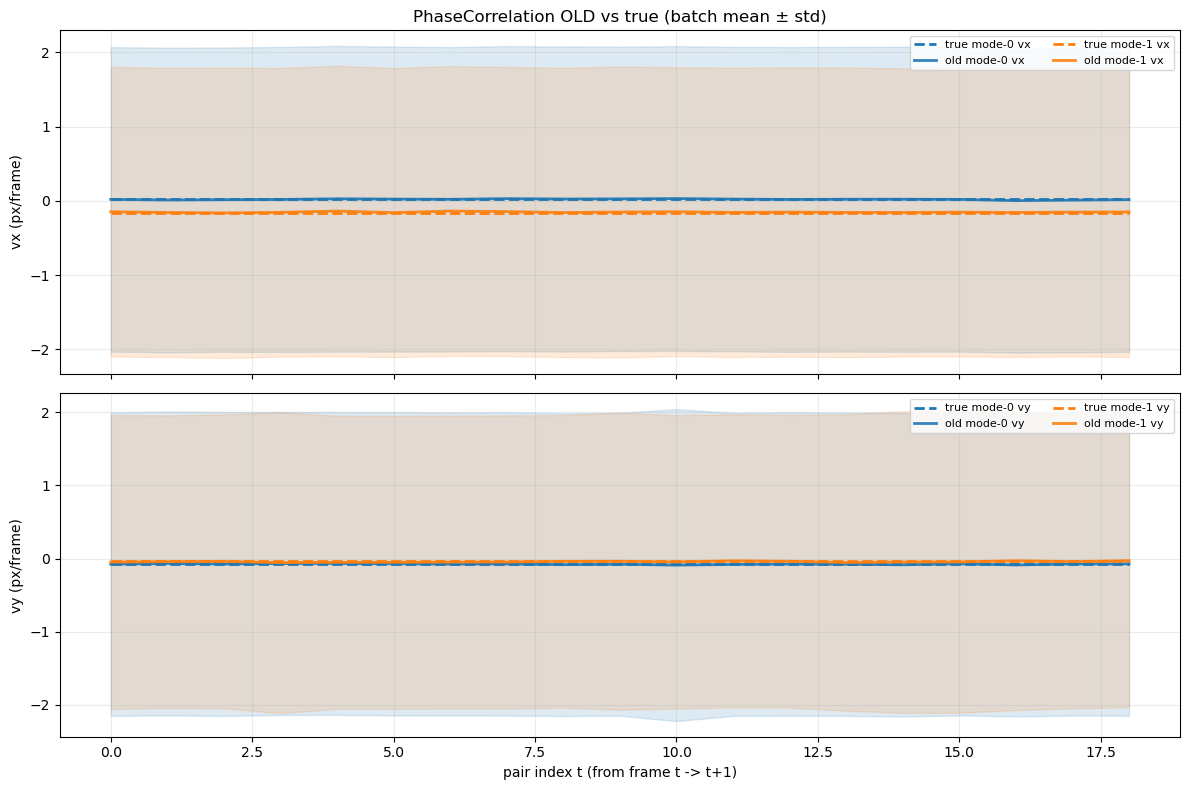

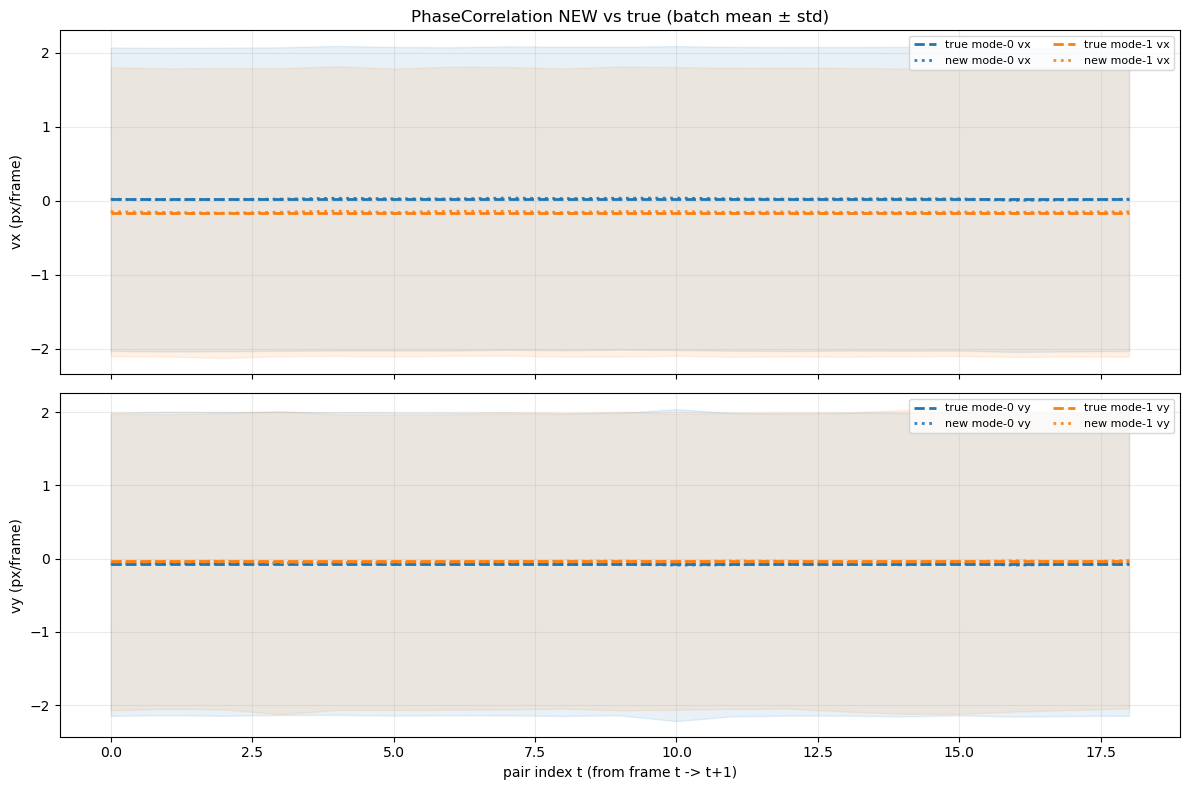

Batch size: 1000, time pairs: 19, modes: 2
Old model:
  Mean L2 error:   0.0202
  Median L2 error: 0.0000
  Time (full sequence): 3372.035 ms
  Time per pair:        177.476 ms
New model:
  Mean L2 error:   0.0835
  Median L2 error: 0.0000
  Time (full sequence): 3378.006 ms
  Time per pair:        177.790 ms
Saved batch sample GIF: media/phase_corr_batch_sample_0.gif
sample labels: [6, 8]
sample true velocities [vx, vy]: [[2.0, -2.0], [-2.0, 2.0]]


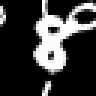

In [14]:
import itertools
import time
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt








# ------------------------
# Config
# ------------------------
batch_size = 1000
num_digits = 2
seq_len = 20
image_size = 32
velocity_range_x = (-3, 3)
velocity_range_y = (-3, 3)

# ------------------------
# Build dataset + one batch
# ------------------------
dataset_batch = MovingMNISTDataset(
    root="./data",
    train=True,
    seq_len=seq_len,
    image_size=image_size,
    velocity_range_x=velocity_range_x,
    velocity_range_y=velocity_range_y,
    num_digits=num_digits,
    random=True,
    return_velocity=True,
    avoid_duplicate_velocity_vectors=True,
)

loader = DataLoader(dataset_batch, batch_size=batch_size, shuffle=True)
seq_batch, labels_batch, true_vel_batch = next(iter(loader))
# seq_batch: (B, T, C, H, W)
# true_vel_batch: (B, num_digits, 2)

B, T, C, H, W = seq_batch.shape
K_true = true_vel_batch.shape[1]
K = min(num_digits, K_true)

# ------------------------
# Models
# ------------------------
pc_old = PhaseCorrelation(
    n_modes=num_digits,
    periodic_bc=True,
    subpixel=False,
    sorting_velocities=True,
)

pc_new = PhaseCorrelation_new(
    n_modes=num_digits,
    periodic_bc=True,
    subpixel=False,
    sorting_velocities=True,
        merge_threshold=1.5,  # new parameter to test
)


def best_perm_align(pred_k2: torch.Tensor, true_k2: torch.Tensor) -> torch.Tensor:
    """
    Align predicted modes to true modes by minimum total L2 error.
    pred_k2: (Kp, 2), true_k2: (Kt, 2)
    returns: reordered pred with shape (K, 2), where K=min(Kp, Kt)
    """
    k = min(pred_k2.shape[0], true_k2.shape[0])
    pred = pred_k2[:k]
    true = true_k2[:k]

    best_cost = None
    best_pred = None
    for perm in itertools.permutations(range(k)):
        perm_t = torch.tensor(perm, dtype=torch.long)
        pred_perm = pred[perm_t]
        cost = torch.norm(pred_perm - true, dim=1).sum()
        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_pred = pred_perm
    return best_pred


def run_model_over_sequence(model, seq_batch, true_vel_batch, K):
    pred_aligned = torch.zeros(B, T - 1, K, 2, dtype=torch.float32)
    t0 = time.perf_counter()
    with torch.no_grad():
        for t in range(T - 1):
            pred_t = model(seq_batch[:, t], seq_batch[:, t + 1])  # (B, n_modes, 2)
            pred_t = pred_t[:, :K, :]
            for b in range(B):
                pred_aligned[b, t] = best_perm_align(pred_t[b], true_vel_batch[b, :K, :])
    elapsed_ms = (time.perf_counter() - t0) * 1000.0
    return pred_aligned, elapsed_ms


# ------------------------
# Predict with old and new models
# ------------------------
true_time = true_vel_batch[:, :K, :].unsqueeze(1).repeat(1, T - 1, 1, 1)

pred_old, time_old_ms = run_model_over_sequence(pc_old, seq_batch, true_vel_batch, K)
pred_new, time_new_ms = run_model_over_sequence(pc_new, seq_batch, true_vel_batch, K)

# ------------------------
# Aggregate
# ------------------------
old_mean = pred_old.mean(dim=0).numpy()                # (T-1, K, 2)
old_std = pred_old.std(dim=0, unbiased=False).numpy()  # avoid warning for B=1
new_mean = pred_new.mean(dim=0).numpy()
new_std = pred_new.std(dim=0, unbiased=False).numpy()
true_mean = true_time.mean(dim=0).numpy()

time_axis = np.arange(T - 1)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

# ------------------------
# Plot 1: OLD vs TRUE
# ------------------------
fig_old, axes_old = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for m in range(K):
    c = colors[m % len(colors)]
    axes_old[0].plot(time_axis, true_mean[:, m, 0], color=c, linestyle="--", linewidth=2, label=f"true mode-{m} vx")
    axes_old[0].plot(time_axis, old_mean[:, m, 0], color=c, linewidth=2, alpha=0.9, label=f"old mode-{m} vx")
    axes_old[0].fill_between(
        time_axis,
        old_mean[:, m, 0] - old_std[:, m, 0],
        old_mean[:, m, 0] + old_std[:, m, 0],
        color=c,
        alpha=0.15,
    )

axes_old[0].set_ylabel("vx (px/frame)")
axes_old[0].set_title("PhaseCorrelation OLD vs true (batch mean ± std)")
axes_old[0].grid(alpha=0.25)
axes_old[0].legend(fontsize=8, ncol=2)

for m in range(K):
    c = colors[m % len(colors)]
    axes_old[1].plot(time_axis, true_mean[:, m, 1], color=c, linestyle="--", linewidth=2, label=f"true mode-{m} vy")
    axes_old[1].plot(time_axis, old_mean[:, m, 1], color=c, linewidth=2, alpha=0.9, label=f"old mode-{m} vy")
    axes_old[1].fill_between(
        time_axis,
        old_mean[:, m, 1] - old_std[:, m, 1],
        old_mean[:, m, 1] + old_std[:, m, 1],
        color=c,
        alpha=0.15,
    )

axes_old[1].set_xlabel("pair index t (from frame t -> t+1)")
axes_old[1].set_ylabel("vy (px/frame)")
axes_old[1].grid(alpha=0.25)
axes_old[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# ------------------------
# Plot 2: NEW vs TRUE
# ------------------------
fig_new, axes_new = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for m in range(K):
    c = colors[m % len(colors)]
    axes_new[0].plot(time_axis, true_mean[:, m, 0], color=c, linestyle="--", linewidth=2, label=f"true mode-{m} vx")
    axes_new[0].plot(time_axis, new_mean[:, m, 0], color=c, linewidth=2, alpha=0.9, linestyle=":", label=f"new mode-{m} vx")
    axes_new[0].fill_between(
        time_axis,
        new_mean[:, m, 0] - new_std[:, m, 0],
        new_mean[:, m, 0] + new_std[:, m, 0],
        color=c,
        alpha=0.10,
    )

axes_new[0].set_ylabel("vx (px/frame)")
axes_new[0].set_title("PhaseCorrelation NEW vs true (batch mean ± std)")
axes_new[0].grid(alpha=0.25)
axes_new[0].legend(fontsize=8, ncol=2)

for m in range(K):
    c = colors[m % len(colors)]
    axes_new[1].plot(time_axis, true_mean[:, m, 1], color=c, linestyle="--", linewidth=2, label=f"true mode-{m} vy")
    axes_new[1].plot(time_axis, new_mean[:, m, 1], color=c, linewidth=2, alpha=0.9, linestyle=":", label=f"new mode-{m} vy")
    axes_new[1].fill_between(
        time_axis,
        new_mean[:, m, 1] - new_std[:, m, 1],
        new_mean[:, m, 1] + new_std[:, m, 1],
        color=c,
        alpha=0.10,
    )

axes_new[1].set_xlabel("pair index t (from frame t -> t+1)")
axes_new[1].set_ylabel("vy (px/frame)")
axes_new[1].grid(alpha=0.25)
axes_new[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# ------------------------
# Error + timing summary
# ------------------------
err_old = torch.norm(pred_old - true_time, dim=-1)  # (B, T-1, K)
err_new = torch.norm(pred_new - true_time, dim=-1)

print(f"Batch size: {B}, time pairs: {T-1}, modes: {K}")
print("Old model:")
print(f"  Mean L2 error:   {err_old.mean().item():.4f}")
print(f"  Median L2 error: {err_old.median().item():.4f}")
print(f"  Time (full sequence): {time_old_ms:.3f} ms")
print(f"  Time per pair:        {time_old_ms / max(T-1, 1):.3f} ms")

print("New model:")
print(f"  Mean L2 error:   {err_new.mean().item():.4f}")
print(f"  Median L2 error: {err_new.median().item():.4f}")
print(f"  Time (full sequence): {time_new_ms:.3f} ms")
print(f"  Time per pair:        {time_new_ms / max(T-1, 1):.3f} ms")

# ------------------------
# Show GIF for one sequence in this batch
# ------------------------
from IPython.display import Image, display

sample_idx = 0
seq_sample = seq_batch[sample_idx]  # (T, C, H, W)

if "sequence_to_gif" in globals():
    gif_path = sequence_to_gif(
        seq_sample,
        save_path=f"media/phase_corr_batch_sample_{sample_idx}.gif",
        fps=8,
        upscale=3,
    )
else:
    import os
    from PIL import Image as PILImage

    seq_np = seq_sample.detach().cpu().numpy()
    if seq_np.ndim == 4 and seq_np.shape[1] == 1:
        seq_np = seq_np[:, 0]

    frames_u8 = (seq_np * 255.0).clip(0, 255).astype(np.uint8)
    pil_frames = []
    for frame in frames_u8:
        img = PILImage.fromarray(frame, mode="L")
        img = img.resize((img.width * 3, img.height * 3), PILImage.NEAREST)
        pil_frames.append(img)

    gif_path = f"media/phase_corr_batch_sample_{sample_idx}.gif"
    os.makedirs("media", exist_ok=True)
    pil_frames[0].save(
        gif_path,
        save_all=True,
        append_images=pil_frames[1:],
        duration=125,
        loop=0,
        optimize=False,
    )

print(f"Saved batch sample GIF: {gif_path}")
print("sample labels:", labels_batch[sample_idx].tolist() if hasattr(labels_batch[sample_idx], "tolist") else labels_batch[sample_idx])
print("sample true velocities [vx, vy]:", true_vel_batch[sample_idx].tolist())
display(Image(filename=gif_path))

# RAFT model tests

In [ ]:
from torchvision.models.optical_flow import raft_large


/mmfs1/cm/shared/apps_local/python/3.11/envs/torch2.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## RAFT test import
Import the RAFT Moving-MNIST test module (no execution yet).

In [ ]:
import os
import sys

repo_root = os.getcwd()
module_dir = os.path.join(repo_root, "moving_mnist_fp")
if module_dir not in sys.path:
    sys.path.append(module_dir)

import test_raft_on_mnist as raft_mnist

print("Imported RAFT module:", raft_mnist.__name__)
print("Script path:", raft_mnist.__file__)

Imported RAFT module: test_raft_on_mnist
Script path: /mmfs1/home/jacks.local/vhosseinzadehjavari/FERNN-master new start/moving_mnist_fp/test_raft_on_mnist.py


In [8]:
import os
import shlex
import subprocess
import sys

repo_root = os.getcwd()
script_path = os.path.join(repo_root, "moving_mnist_fp", "test_raft_on_mnist.py")

# Edit these arguments as needed
args = [
    "--root", "./data",
    "--seq_len", "20",
    "--image_size", "64",
    "--num_digits", "1",
    "--sample_index", "0",
    "--max_pairs", "8",
    "--upscale", "4",
    "--velocity", "2",
    "--fg_thresh", "0.08",
    "--out_dir", "./tmp/raft_mnist",
]

cmd = [sys.executable, script_path] + args
print("Running:", " ".join(shlex.quote(x) for x in cmd))

try:
    import torchvision  # noqa: F401
except Exception as exc:
    print("torchvision is not available in this notebook kernel.")
    print("Install it first, then rerun this cell.")
    print(f"Import error: {exc}")
else:
    proc = subprocess.run(cmd, capture_output=True, text=True)
    print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(f"RAFT run failed with exit code {proc.returncode}")
    print("Saved RAFT visualizations to ./tmp/raft_mnist")

Running: /mmfs1/cm/shared/apps_local/python/3.11/envs/torch2.2/bin/python '/mmfs1/home/jacks.local/vhosseinzadehjavari/FERNN-master new start/moving_mnist_fp/test_raft_on_mnist.py' --root ./data --seq_len 20 --image_size 64 --num_digits 1 --sample_index 0 --max_pairs 8 --upscale 4 --velocity 2 --fg_thresh 0.08 --out_dir ./tmp/raft_mnist
Device: cpu
Sequence shape: (20, 1, 64, 64)
Label: 1
Foreground threshold: 0.08
Saving 8 visualizations to: ./tmp/raft_mnist
pair 00 | mean|flow| (fg): 8.375 | median|flow| (fg): 8.371
pair 01 | mean|flow| (fg): 9.028 | median|flow| (fg): 9.039
pair 02 | mean|flow| (fg): 8.604 | median|flow| (fg): 8.567
pair 03 | mean|flow| (fg): 8.960 | median|flow| (fg): 8.966
pair 04 | mean|flow| (fg): 8.592 | median|flow| (fg): 8.595
pair 05 | mean|flow| (fg): 9.084 | median|flow| (fg): 9.095
pair 06 | mean|flow| (fg): 8.674 | median|flow| (fg): 8.655
pair 07 | mean|flow| (fg): 9.086 | median|flow| (fg): 9.093
Done.

Saved RAFT visualizations to ./tmp/raft_mnist


In [16]:

import argparse, random, re, urllib.request, zipfile
from pathlib import Path
from typing import Dict, List, Tuple
import os
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import wandb

_BASE = "http://www.csc.kth.se/cvap/actions/"
_ACTIONS = [
    ("walking",      242),
    ("jogging",      168),
    ("running",      149),
    ("boxing",       194),
    ("handwaving",   218),
    ("handclapping", 176),
]
_ACTION2IDX = {name: idx for idx, (name, _) in enumerate(_ACTIONS)}
_SEQ_TXT = "00sequences.txt"


# ===========================================================================
# Utils
# ===========================================================================

def _human(mib: int) -> str:
    return f"{mib}\u00a0MB" if mib < 1024 else f"{mib/1024:.1f}\u00a0GB"


def _safe_dl(url: str, dst: Path) -> Path:
    """Download *url* to *dst* unless it already exists."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return dst
    with urllib.request.urlopen(url) as resp, open(dst, "wb") as fh:
        total = int(resp.getheader("Content-Length", "0"))
        pbar = tqdm(total=total, unit="B", unit_scale=True,
                    desc=f"⬇ {dst.name}")
        while buf := resp.read(16 << 10):
            fh.write(buf); pbar.update(len(buf))
        pbar.close()
    return dst


def _download_kth(root: Path) -> Path:
    """Ensure the KTH archives + annotation file are present; return video dir."""
    root = root.expanduser()
    video_dir = root / "kth_actions"
    video_dir.mkdir(parents=True, exist_ok=True)

    # annotation list
    _safe_dl(_BASE + _SEQ_TXT, root / _SEQ_TXT)

    # each action archive
    for act, mib in _ACTIONS:
        zip_path = root / f"{act}.zip"
        if not zip_path.exists():
            print(f"Downloading {act} ({_human(mib)}) …")
            _safe_dl(_BASE + f"{act}.zip", zip_path)
        marker = video_dir / f".{act}_unzipped"
        if not marker.exists():
            print(f"🗜️  Extracting {zip_path.name} …")
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(video_dir)
            marker.touch()
    return video_dir


def preprocess_videos(video_dir: Path, hdf5_path: Path, height: int = 64, width: int = 64) -> None:
    """Pre-extract frames from all videos into a single HDF5 file."""
    if hdf5_path.exists():
        return
        
    def process_video(video_path: Path) -> Tuple[str, np.ndarray]:
        video_name = video_path.stem
        if video_name.endswith("_uncomp"):
            video_name = video_name[:-7]
            
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # Convert to grayscale and resize
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_AREA)
            frames.append(gray)
        cap.release()
        return video_name, np.stack(frames)
    
    # Process all videos in parallel
    video_paths = list(video_dir.glob("*.avi"))
    print(f"Pre-extracting frames from {len(video_paths)} videos...")
    
    # Create HDF5 file
    with h5py.File(hdf5_path, 'w') as f:
        with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
            futures = [executor.submit(process_video, vp) for vp in video_paths]
            for future in tqdm(futures, total=len(video_paths)):
                video_name, frames = future.result()
                f.create_dataset(video_name, data=frames, compression='gzip', compression_opts=1)



# tests on KTH dataset

In [17]:

# ===========================================================================
# Dataset
# ===========================================================================

class KTHVideoClips(Dataset):
    """Return `(clip, label)` where *clip* has shape `(T,1,H,W)` and label∈[0,5]."""

    _LINE_RE = re.compile(r"^(?P<fname>\S+)\s+frames\s+(?P<ranges>[\d,\s\-]+)$")

    def __init__(self,
                 root: Path,
                 seq_len: int = 16,
                 height: int = 64,
                 width: int | None = None,
                 step: int = 1,
                 split: str = 'train',  # 'train', 'val', or 'test'
                 vx_data_range: int = 0,
                 vy_data_range: int = 0,
                 split_method: str = 'person'):  # 'person' or 'random'
        self.video_root = _download_kth(root)
        self.hdf5_path = root / "kth_frames.h5"
        self.seq_len, self.step = seq_len, step
        self.h, self.w = height, width or height
        self.split = split
        self.vx_data_range = vx_data_range
        self.vy_data_range = vy_data_range
        self.split_method = split_method
        
        # Pre-extract frames if needed
        if not self.hdf5_path.exists():
            print("Pre-extracting frames for faster loading...")
            preprocess_videos(self.video_root, self.hdf5_path, height, width)
        
        # Load entire dataset into memory
        print("Loading dataset into memory...")
        self.frames_dict = {}
        with h5py.File(self.hdf5_path, 'r') as f:
            for video_name in tqdm(f.keys(), desc="Loading videos"):
                self.frames_dict[video_name] = f[video_name][:]  # Load entire video into memory
        
        # Parse annotation file and split sequences
        self.sequences: List[Tuple[str,int,int]] = []
        self._parse_sequences(root / _SEQ_TXT)
        
        # Generate deterministic velocities for each sequence
        if vx_data_range > 0 or vy_data_range > 0:
            print("Generating deterministic velocities for data augmentation...")
            # Use a fixed seed for reproducibility
            rng = np.random.RandomState(42)
            self.velocities = []
            for _ in range(len(self.sequences)):
                vx = rng.randint(-vx_data_range, vx_data_range + 1)
                vy = rng.randint(-vy_data_range, vy_data_range + 1)
                self.velocities.append((vy, vx))  # Note: (vy, vx) to match kernel dimensions
            print(f"Generated {len(self.velocities)} velocity vectors")
        else:
            self.velocities = None
            
        print(f"Dataset loaded into memory. Total size: {sum(frames.nbytes for frames in self.frames_dict.values()) / (1024**3):.2f} GB")

    def _parse_sequences(self, txt_path: Path):
        # First collect all sequences
        all_sequences = []
        with open(txt_path) as fh:
            for line in fh:
                m = self._LINE_RE.match(line.strip())
                if not m: continue
                vname = m.group("fname")
                rng_blob = m.group("ranges")
                vpath = self.video_root / f"{vname}_uncomp.avi"
                if not vpath.exists(): continue
                
                # Get frame count from memory
                if vname not in self.frames_dict: continue
                total_frames = len(self.frames_dict[vname])
                
                for rng in rng_blob.split(','):
                    rng = rng.strip()
                    if not rng: continue
                    if '-' in rng:
                        s, e = map(int, rng.split('-'))
                    else:
                        s = e = int(rng)
                    e = min(e, total_frames - 1)
                    if e - s + 1 >= self.seq_len * self.step:
                        all_sequences.append((vname, s, e))

        if self.split_method == 'person':
            # Split sequences by person ID
            train_sequences = []
            val_sequences = []
            test_sequences = []
            
            for vname, s, e in all_sequences:
                # Extract person ID from video name (e.g., "person01_boxing_d1" -> "01")
                person_id = int(vname.split('_')[0][6:8])
                
                if person_id <= 16:
                    train_sequences.append((vname, s, e))
                elif person_id <= 20:
                    val_sequences.append((vname, s, e))
                else:  # person_id 21-25
                    test_sequences.append((vname, s, e))
        else:  # random split
            # Use a fixed random seed for reproducibility
            rng = np.random.RandomState(42)
            # Shuffle sequences
            rng.shuffle(all_sequences)
            # Split into train (70%), val (15%), test (15%)
            n = len(all_sequences)
            train_size = int(0.7 * n)
            val_size = int(0.15 * n)
            
            train_sequences = all_sequences[:train_size]
            val_sequences = all_sequences[train_size:train_size + val_size]
            test_sequences = all_sequences[train_size + val_size:]

        # Assign sequences based on split
        if self.split == 'train':
            self.sequences = train_sequences
        elif self.split == 'val':
            self.sequences = val_sequences
        else:  # test
            self.sequences = test_sequences

        print(f"Loaded {len(self.sequences):,} valid subsequences for {self.split} split using {self.split_method} method.")

    def __len__(self):
        return len(self.sequences)

    def _apply_velocity_shift(self, frame, vy, vx):
        """Apply velocity shift to a single frame using circular padding,
        but reduce shift & pad modulo the frame dimensions so you never
        wrap more than once."""
        _, H, W = frame.shape

        # 1) reduce the shift itself modulo the spatial dims
        #    (so a shift of -1 becomes H-1, equivalent to one left wrap)
        vy = vy % H
        vx = vx % W

        if vy == 0 and vx == 0:
            return frame

        # 2) build a single‐pixel “shift” kernel
        max_shift = max(vy, vx)
        kernel_size = max_shift * 2 + 1
        shift_kernel = torch.zeros(1, 1, kernel_size, kernel_size,
                                    device=frame.device, dtype=frame.dtype)
        center = kernel_size // 2
        shift_kernel[0, 0, center + vy, center + vx] = 1.0

        # 3) effective pad is ≤ H and ≤ W
        pad_y = max_shift % H or H    # if max_shift % H == 0, we want a full H wrap
        pad_x = max_shift % W or W

        # F.pad takes (pad_left, pad_right, pad_top, pad_bottom)
        padded = F.pad(frame,
                        (pad_x, pad_x, pad_y, pad_y),
                        mode='circular')

        # 4) convolve the one‐pixel kernel over each channel
        shifted = F.conv2d(padded,
                            shift_kernel,
                            padding=0)
        return shifted

    def __getitem__(self, idx):
        vname, s, e = self.sequences[idx]
        max_start = e - self.seq_len * self.step + 1
        start = random.randint(s, max_start)
        
        # Load frames from memory
        frames = []
        for i in range(self.seq_len):
            frame_idx = start + i * self.step
            frame = self.frames_dict[vname][frame_idx]
            frame = torch.from_numpy(frame).float().unsqueeze(0) / 255.0
            frames.append(frame)
        
        clip = torch.stack(frames, dim=0)  # (T,1,H,W)

        # Apply velocity shift if enabled
        if self.velocities is not None:
            vy, vx = self.velocities[idx]
            shifted_frames = []
            for t, frame in enumerate(clip):
                # Apply accumulated shift: velocity * time
                shift_y = vy * t
                shift_x = vx * t
                shifted = self._apply_velocity_shift(frame, shift_y, shift_x)
                shifted_frames.append(shifted)
            clip = torch.stack(shifted_frames, dim=0)

        # augmentations
        if self.split == 'train':
            if random.random() < 0.5:
                clip = torch.flip(clip, dims=[3])      # horizontal flip

        # label from video name
        action = vname.split('_')[1]
        label = _ACTION2IDX[action]
        return clip, label


In [18]:
# Create datasets for each split
train_dataset = KTHVideoClips(
    Path("./data/kth/"), 
    seq_len=16, 
    height=32, 
    width=32, 
    step=2, 
    split='train',
    vx_data_range=0,
    vy_data_range=0,
    split_method='person'
)

Loading dataset into memory...


Loading videos: 100%|██████████| 599/599 [00:03<00:00, 162.00it/s]

Loaded 1,517 valid subsequences for train split using person method.
Dataset loaded into memory. Total size: 0.28 GB


In [19]:
# Create datasets for each split
train_dataset = KTHVideoClips(
    Path("./data/kth/"), 
    seq_len=16, 
    height=64, 
    width=64, 
    step=2, 
    split='train',
    vx_data_range=1,
    vy_data_range=1,
    split_method='person'
)

Loading dataset into memory...


Loading videos: 100%|██████████| 599/599 [00:02<00:00, 254.79it/s]

Loaded 1,517 valid subsequences for train split using person method.
Generating deterministic velocities for data augmentation...
Generated 1517 velocity vectors
Dataset loaded into memory. Total size: 0.28 GB


In [20]:
import os
import random
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import Image, display

def show_random_kth_video(dataset, fps=8, upscale=3, out_dir="media", seed=None):
    """
    Show one random datapoint from KTHVideoClips as a GIF.
    Returns: (idx, clip, label, gif_path)
    """
    if seed is not None:
        random.seed(seed)

    idx = random.randint(0, len(dataset) - 1)
    clip, label = dataset[idx]  # clip: (T,1,H,W), label: int

    os.makedirs(out_dir, exist_ok=True)
    gif_path = os.path.join(out_dir, f"kth_random_{idx}.gif")

    # Use existing helper if available
    if "sequence_to_gif" in globals():
        sequence_to_gif(clip, save_path=gif_path, fps=fps, upscale=upscale)
    else:
        # Fallback GIF writer
        seq = clip.detach().cpu().numpy()
        if seq.ndim == 4 and seq.shape[1] == 1:
            seq = seq[:, 0]  # (T,H,W)
        frames_u8 = (np.clip(seq, 0, 1) * 255).astype(np.uint8)

        pil_frames = []
        for frame in frames_u8:
            img = PILImage.fromarray(frame, mode="L")
            if upscale > 1:
                img = img.resize((img.width * upscale, img.height * upscale), PILImage.NEAREST)
            pil_frames.append(img)

        duration_ms = int(1000 / max(fps, 1))
        pil_frames[0].save(
            gif_path,
            save_all=True,
            append_images=pil_frames[1:],
            duration=duration_ms,
            loop=0,
            optimize=False,
        )

    # Decode label name if _ACTIONS exists
    action_name = None
    if "_ACTIONS" in globals():
        idx2action = {i: name for i, (name, _) in enumerate(_ACTIONS)}
        action_name = idx2action.get(int(label), None)

    print(f"Random index: {idx}")
    print(f"Label: {int(label)}" + (f" ({action_name})" if action_name else ""))
    print(f"Saved GIF: {gif_path}")
    display(Image(filename=gif_path))

    return idx, clip, label, gif_path

# Example usage:
# show_random_kth_video(train_dataset, fps=10, upscale=3)

Random index: 1309
Label: 2 (running)
Saved GIF: media/kth_random_1309.gif


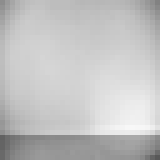

(1309,
 tensor([[[[0.5529, 0.6078, 0.6510,  ..., 0.5961, 0.5608, 0.5098],
           [0.5765, 0.6235, 0.6667,  ..., 0.6157, 0.5804, 0.5373],
           [0.6039, 0.6588, 0.6941,  ..., 0.6510, 0.6157, 0.5725],
           ...,
           [0.3922, 0.4353, 0.4824,  ..., 0.5765, 0.5451, 0.5020],
           [0.4118, 0.4627, 0.5020,  ..., 0.5451, 0.5137, 0.4275],
           [0.4118, 0.4667, 0.5176,  ..., 0.4706, 0.3922, 0.3451]]],
 
 
         [[[0.5373, 0.5765, 0.6235,  ..., 0.6471, 0.6157, 0.5843],
           [0.5725, 0.6039, 0.6549,  ..., 0.6824, 0.6471, 0.6157],
           [0.6000, 0.6275, 0.6824,  ..., 0.7020, 0.6784, 0.6431],
           ...,
           [0.4275, 0.4157, 0.4627,  ..., 0.5765, 0.5412, 0.5059],
           [0.3412, 0.4118, 0.4706,  ..., 0.5333, 0.4667, 0.3882],
           [0.5098, 0.5529, 0.6078,  ..., 0.6314, 0.6000, 0.5608]]],
 
 
         [[[0.6118, 0.5647, 0.6039,  ..., 0.7059, 0.6784, 0.6431],
           [0.6353, 0.5882, 0.6275,  ..., 0.7216, 0.6980, 0.6706],
           

In [21]:
show_random_kth_video(train_dataset, fps=8, upscale=5, seed=42)

In [22]:
import math
import torch
import matplotlib.pyplot as plt


def _parabolic_subpixel_2d(corr, y, x):
    """
    corr: (H, W)
    y, x: (K,) integer peak coordinates
    returns: dy, dx (K,) subpixel offsets
    """
    H, W = corr.shape
    y = y.long()
    x = x.long()

    xm1 = (x - 1) % W
    xp1 = (x + 1) % W
    ym1 = (y - 1) % H
    yp1 = (y + 1) % H

    c = corr[y, x]

    c_xm1 = corr[y, xm1]
    c_xp1 = corr[y, xp1]
    denom_x = c_xm1 - 2 * c + c_xp1
    dx = torch.where(
        torch.abs(denom_x) < 1e-12,
        torch.zeros_like(denom_x),
        0.5 * (c_xm1 - c_xp1) / denom_x,
    )

    c_ym1 = corr[ym1, x]
    c_yp1 = corr[yp1, x]
    denom_y = c_ym1 - 2 * c + c_yp1
    dy = torch.where(
        torch.abs(denom_y) < 1e-12,
        torch.zeros_like(denom_y),
        0.5 * (c_ym1 - c_yp1) / denom_y,
    )

    return dy, dx


def _phase_corr_map(frame_prev, frame_next, pad_factor=1, eps=1e-8, subpixel=True, periodic_bc=True, n_modes=1):
    """
    frame_prev, frame_next: (H,W) or (1,H,W) or (C,H,W)

    Returns:
        corr: (H_pad, W_pad)
        velocities: (K, 2) with (vx, vy)
        topk_vals: (K,)
        peaks_xy: (K, 2) in centered coordinates (x, y), if periodic_bc=True
    """
    if frame_prev.ndim == 3:
        frame_prev = frame_prev.mean(dim=0)
    if frame_next.ndim == 3:
        frame_next = frame_next.mean(dim=0)

    H, W = frame_prev.shape
    H_pad, W_pad = H * pad_factor, W * pad_factor

    F0 = torch.fft.rfft2(frame_prev, s=(H_pad, W_pad))
    F1 = torch.fft.rfft2(frame_next, s=(H_pad, W_pad))

    R = F0 * torch.conj(F1)
    R = R / (torch.abs(R) + eps)

    corr = torch.fft.irfft2(R, s=(H_pad, W_pad))

    corr_flat = corr.reshape(-1)
    K = min(max(int(n_modes), 1), corr_flat.numel())
    topk_vals, topk_idx = torch.topk(corr_flat, K)

    y0 = (topk_idx // W_pad).long()
    x0 = (topk_idx % W_pad).long()

    y = y0.float()
    x = x0.float()

    if subpixel:
        dy, dx = _parabolic_subpixel_2d(corr, y0, x0)
        y = y + dy
        x = x + dx

    if periodic_bc:
        x = torch.where(x > W_pad / 2, x - W_pad, x)
        y = torch.where(y > H_pad / 2, y - H_pad, y)

    vx = -x
    vy = -y
    velocities = torch.stack([vx, vy], dim=1)  # (K,2)
    peaks_xy = torch.stack([x, y], dim=1)      # (K,2)

    return corr, velocities, topk_vals, peaks_xy


def show_random_kth_with_phase_correlations(
    dataset,
    seed=None,
    fps=8,
    upscale=6,
    out_dir="media",
    pad_factor=1,
    eps=1e-8,
    ncols=5,
    cmap="viridis",
    n_modes=1,
    subpixel=True,
):
    """
    1) Shows one random KTH datapoint as GIF (via show_random_kth_video)
    2) Computes phase-correlation map for each consecutive frame pair
    3) Plots all phase-correlation maps in one figure (grid), centered at (0,0)
    4) Plots summed phase-correlation map, centered at (0,0)
    """
    idx, clip, label, gif_path = show_random_kth_video(
        dataset, fps=fps, upscale=upscale, out_dir=out_dir, seed=seed
    )

    T = clip.shape[0]
    corr_maps = []
    peaks = []
    velocities = []
    topk_scores = []

    for t in range(T - 1):
        corr, vel, topk_vals, peaks_xy = _phase_corr_map(
            clip[t],
            clip[t + 1],
            pad_factor=pad_factor,
            eps=eps,
            subpixel=subpixel,
            periodic_bc=True,
            n_modes=n_modes,
        )
        corr_maps.append(corr.detach().cpu())
        velocities.append(vel.detach().cpu())
        peaks.append(peaks_xy.detach().cpu())
        topk_scores.append(topk_vals.detach().cpu())

    n = len(corr_maps)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)

    im = None
    for i, corr in enumerate(corr_maps):
        r, c = divmod(i, ncols)
        ax = axes[r][c]

        Hc, Wc = corr.shape
        x_min = -(Wc // 2)
        x_max = Wc - Wc // 2 - 1
        y_min = -(Hc // 2)
        y_max = Hc - Hc // 2 - 1

        corr_centered = torch.fft.fftshift(corr)
        im = ax.imshow(
            corr_centered.numpy(),
            cmap=cmap,
            origin="lower",
            extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
            aspect="equal",
        )

        x0, y0 = peaks[i][0].tolist()  # centered coords
        vx0, vy0 = velocities[i][0].tolist()
        ax.scatter([x0], [y0], c="red", s=18)
        ax.axhline(0, color="w", lw=0.4, alpha=0.4)
        ax.axvline(0, color="w", lw=0.4, alpha=0.4)

        ax.set_title(
            f"{i}->{i+1}\\nv=({vx0:.2f},{vy0:.2f}) top1={topk_scores[i][0].item():.3g}",
            fontsize=9,
        )

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis("off")

    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="phase corr")

    plt.suptitle(f"Phase-correlation maps (centered) | sample idx={idx}, label={int(label)}", y=1.02)
    plt.tight_layout()
    plt.show()

    corr_stack = torch.stack(corr_maps, dim=0)
    corr_sum = corr_stack.sum(dim=0)

    Hs, Ws = corr_sum.shape
    x_min = -(Ws // 2)
    x_max = Ws - Ws // 2 - 1
    y_min = -(Hs // 2)
    y_max = Hs - Hs // 2 - 1

    corr_sum_centered = torch.fft.fftshift(corr_sum)
    flat_idx_sum = torch.argmax(corr_sum_centered).item()
    y_idx, x_idx = divmod(flat_idx_sum, Ws)
    x_sum = x_idx + x_min
    y_sum = y_idx + y_min

    plt.figure(figsize=(6, 5))
    plt.imshow(
        corr_sum_centered.numpy(),
        cmap=cmap,
        origin="lower",
        extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
        aspect="equal",
    )
    plt.scatter([x_sum], [y_sum], c="red", s=30, label="peak (sum map)")
    plt.axhline(0, color="w", lw=0.6, alpha=0.5)
    plt.axvline(0, color="w", lw=0.6, alpha=0.5)
    plt.title(f"Summed phase-correlation map (centered) | sample idx={idx}")
    plt.colorbar(label="summed phase corr")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    return {
        "index": idx,
        "label": int(label),
        "gif_path": gif_path,
        # "clip": clip,
        # "corr_maps": corr_maps,
        # "peaks_xy": peaks,
        # "velocities_vx_vy": velocities,
        "topk_scores": topk_scores,
        # "corr_sum": corr_sum,
    }


# Example:
# result = show_random_kth_with_phase_correlations(train_dataset, seed=42, pad_factor=1, ncols=5, n_modes=3, subpixel=True)

Random index: 563
Label: 0 (walking)
Saved GIF: media/kth_random_563.gif


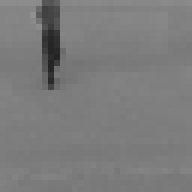

/tmp/ipykernel_4166972/2292885193.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


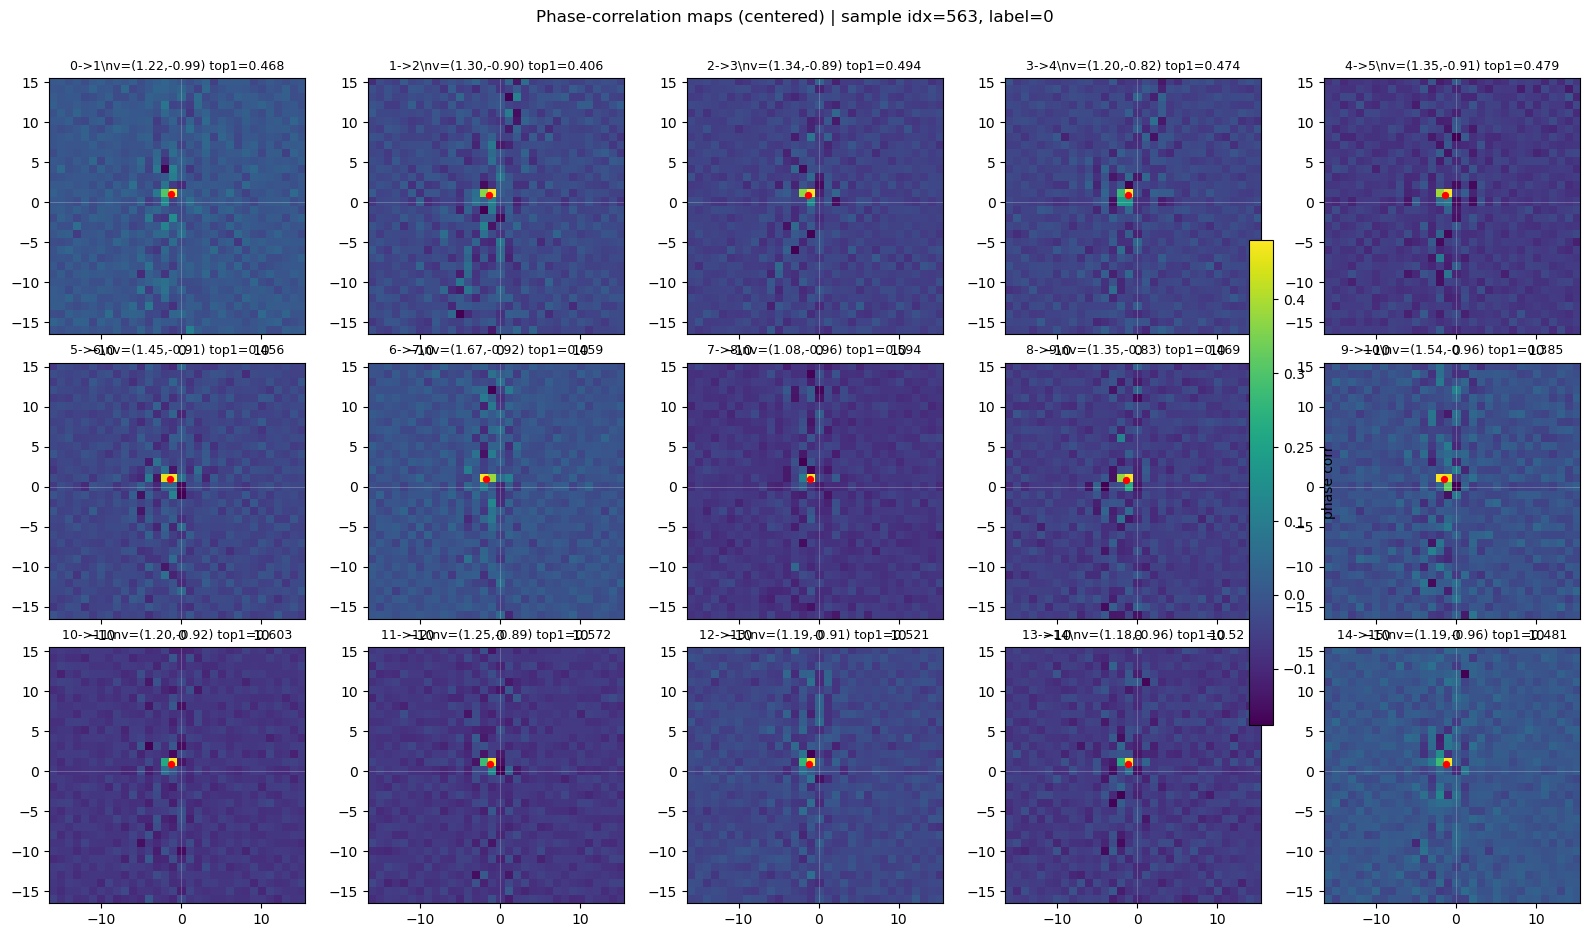

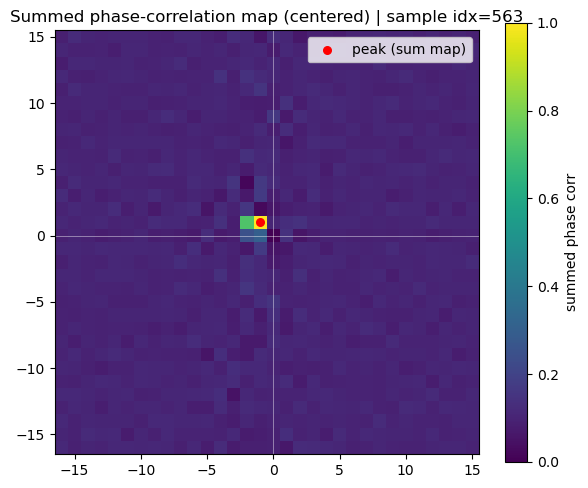

{'index': 563,
 'label': 0,
 'gif_path': 'media/kth_random_563.gif',
 'topk_scores': [tensor([0.4681, 0.2970, 0.1409, 0.1325, 0.1144]),
  tensor([0.4064, 0.3138, 0.1121, 0.1117, 0.1085]),
  tensor([0.4943, 0.3885, 0.1773, 0.1212, 0.0922]),
  tensor([0.4737, 0.2827, 0.2074, 0.1967, 0.0950]),
  tensor([0.4787, 0.3976, 0.1383, 0.1339, 0.1210]),
  tensor([0.4562, 0.4359, 0.1335, 0.1228, 0.0953]),
  tensor([0.4593, 0.3658, 0.1287, 0.1089, 0.1055]),
  tensor([0.5940, 0.1870, 0.1249, 0.1006, 0.0968]),
  tensor([0.4690, 0.3798, 0.2531, 0.1545, 0.1094]),
  tensor([0.3849, 0.3701, 0.2573, 0.0985, 0.0981]),
  tensor([0.6034, 0.3218, 0.1487, 0.0871, 0.0827]),
  tensor([0.5716, 0.3568, 0.2163, 0.1080, 0.0869]),
  tensor([0.5208, 0.2966, 0.1120, 0.1118, 0.1062]),
  tensor([0.5198, 0.2770, 0.1262, 0.1011, 0.0964]),
  tensor([0.4805, 0.2733, 0.1481, 0.1263, 0.0919])]}

In [23]:
show_random_kth_with_phase_correlations(train_dataset, seed=None, pad_factor=1,n_modes=5, ncols=5)

In [24]:
# Example usage:
train_dataset_Mnist = MovingMNISTDataset(
    root='./data',
    train=True,
    seq_len=30,
    image_size=32,
    velocity_range_x=(-5, 5),
    velocity_range_y=(-5, 5),
    num_digits=2,
    return_velocity=True
)

In [25]:
import math
import torch
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display
from PIL import Image as PILImage
import random

def show_random_mnist_with_phase_correlations(
    dataset,
    seed=None,
    fps=8,
    upscale=3,
    out_dir="media",
    pad_factor=1,
    eps=1e-8,
    ncols=5,
    cmap="viridis",
    n_modes=1,
    subpixel=True,
):
    """
    1) Shows one random MovingMNIST sequence as GIF
    2) Computes phase-correlation map for each consecutive frame pair
    3) Plots all phase-correlation maps in one figure (centered at (0,0))
    4) Plots summed phase-correlation map (centered)
    """
    if seed is not None:
        random.seed(seed)

    idx = random.randint(0, len(dataset) - 1)
    seq, label, *vel = dataset[idx]  # seq: (T,1,H,W)

    gif_path = os.path.join(out_dir, f"mnist_random_{idx}.gif")
    os.makedirs(out_dir, exist_ok=True)
    if "sequence_to_gif" in globals():
        sequence_to_gif(seq, save_path=gif_path, fps=fps, upscale=upscale)
    else:
        seq_np = seq.detach().cpu().numpy()
        if seq_np.ndim == 4 and seq_np.shape[1] == 1:
            seq_np = seq_np[:, 0]
        frames_u8 = (np.clip(seq_np, 0, 1) * 255).astype(np.uint8)
        pil_frames = []
        for frame in frames_u8:
            img = PILImage.fromarray(frame, mode="L")
            if upscale > 1:
                img = img.resize((img.width * upscale, img.height * upscale), PILImage.NEAREST)
            pil_frames.append(img)
        duration_ms = int(1000 / max(fps, 1))
        pil_frames[0].save(
            gif_path,
            save_all=True,
            append_images=pil_frames[1:],
            duration=duration_ms,
            loop=0,
            optimize=False,
        )

    print(f"Random index: {idx}")
    print(f"Saved GIF: {gif_path}")
    display(Image(filename=gif_path))

    T = seq.shape[0]
    corr_maps = []
    peaks = []
    velocities = []
    topk_scores = []

    for t in range(T - 1):
        corr, vel, topk_vals, peaks_xy = _phase_corr_map(
            seq[t],
            seq[t + 1],
            pad_factor=pad_factor,
            eps=eps,
            subpixel=subpixel,
            periodic_bc=True,
            n_modes=n_modes,
        )
        corr_maps.append(corr.detach().cpu())
        velocities.append(vel.detach().cpu())
        peaks.append(peaks_xy.detach().cpu())
        topk_scores.append(topk_vals.detach().cpu())

    n = len(corr_maps)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)

    im = None
    for i, corr in enumerate(corr_maps):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        Hc, Wc = corr.shape
        x_min = -(Wc // 2)
        x_max = Wc - Wc // 2 - 1
        y_min = -(Hc // 2)
        y_max = Hc - Hc // 2 - 1
        corr_centered = torch.fft.fftshift(corr)
        im = ax.imshow(
            corr_centered.numpy(),
            cmap=cmap,
            origin="lower",
            extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
            aspect="equal",
        )
        x0, y0 = peaks[i][0].tolist()
        vx0, vy0 = velocities[i][0].tolist()
        ax.scatter([x0], [y0], c="red", s=18)
        ax.axhline(0, color="w", lw=0.4, alpha=0.4)
        ax.axvline(0, color="w", lw=0.4, alpha=0.4)
        ax.set_title(
            f"{i}->{i+1}\nv=({vx0:.2f},{vy0:.2f}) top1={topk_scores[i][0].item():.3g}",
            fontsize=9,
        )

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis("off")

    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="phase corr")

    plt.suptitle(f"Phase-correlation maps (centered) | MNIST sample idx={idx}", y=1.02)
    plt.tight_layout()
    plt.show()

    corr_stack = torch.stack(corr_maps, dim=0)
    corr_sum = corr_stack.sum(dim=0)

    Hs, Ws = corr_sum.shape
    x_min = -(Ws // 2)
    x_max = Ws - Ws // 2 - 1
    y_min = -(Hs // 2)
    y_max = Hs - Hs // 2 - 1
    corr_sum_centered = torch.fft.fftshift(corr_sum)
    flat_idx_sum = torch.argmax(corr_sum_centered).item()
    y_idx, x_idx = divmod(flat_idx_sum, Ws)
    x_sum = x_idx + x_min
    y_sum = y_idx + y_min

    plt.figure(figsize=(6, 5))
    plt.imshow(
        corr_sum_centered.numpy(),
        cmap=cmap,
        origin="lower",
        extent=[x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5],
        aspect="equal",
    )
    plt.scatter([x_sum], [y_sum], c="red", s=30, label="peak (sum map)")
    plt.axhline(0, color="w", lw=0.6, alpha=0.5)
    plt.axvline(0, color="w", lw=0.6, alpha=0.5)
    plt.title(f"Summed phase-correlation map (centered) | MNIST sample idx={idx}")
    plt.colorbar(label="summed phase corr")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    return {
        "index": idx,
        "gif_path": gif_path,
        "seq": seq,
        "corr_maps": corr_maps,
        "peaks_xy": peaks,
        "velocities_vx_vy": velocities,
        "topk_scores": topk_scores,
        "corr_sum": corr_sum,
    }

# Example usage:
# show_random_mnist_with_phase_correlations(dataset_batch, seed=1, pad_factor=1, n_modes=2, ncols=5)

Random index: 48265
Saved GIF: media/mnist_random_48265.gif


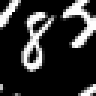

/tmp/ipykernel_4166972/1596326939.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


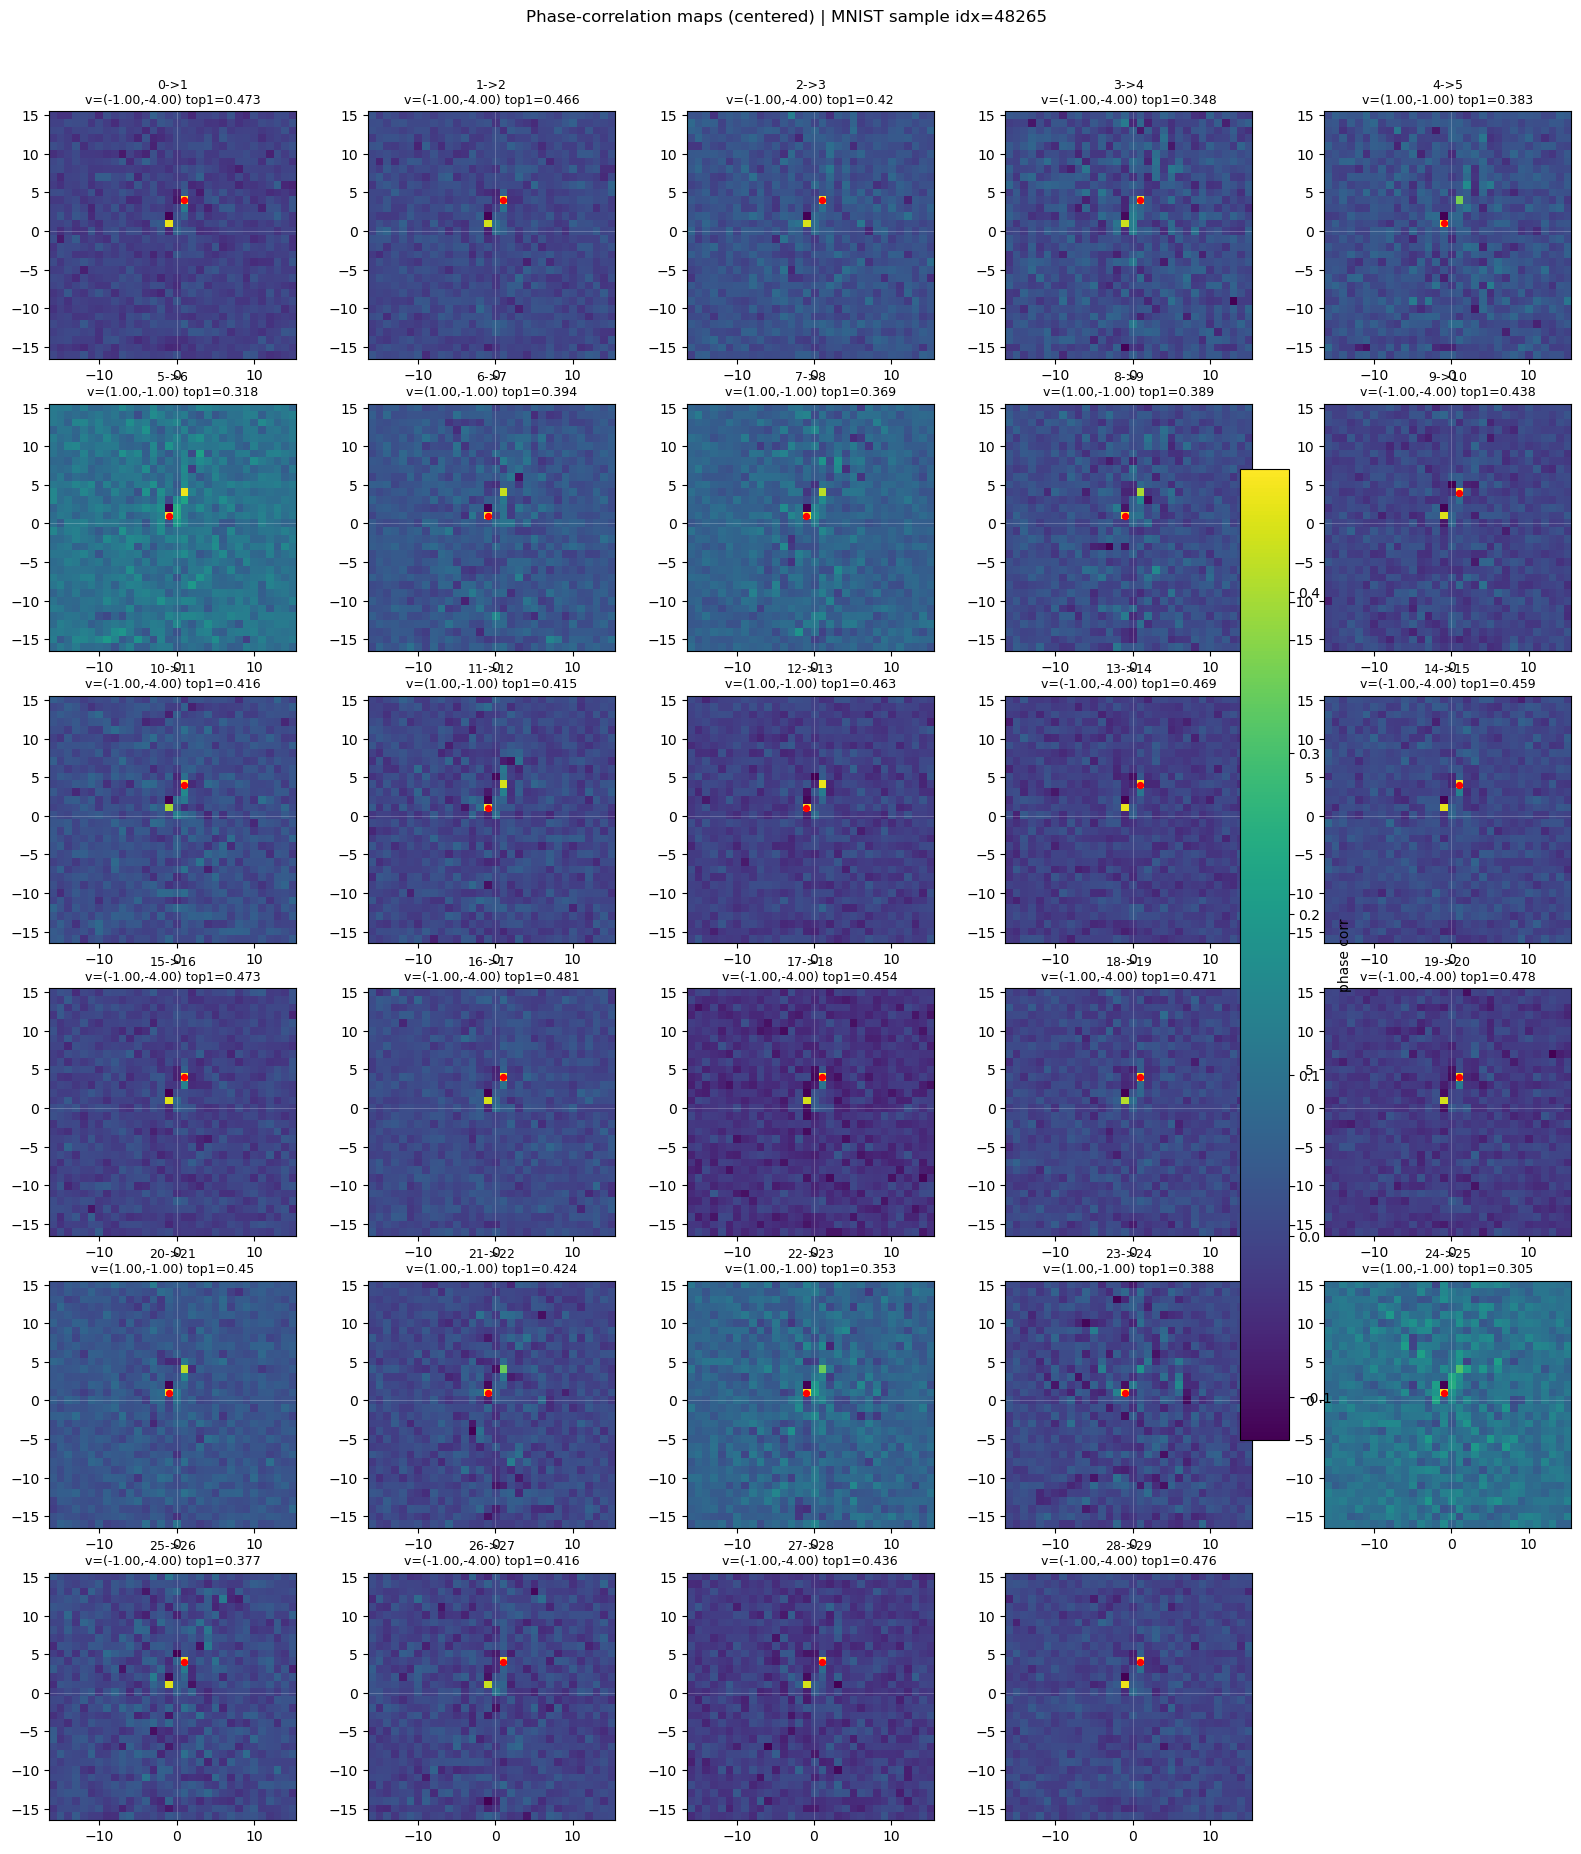

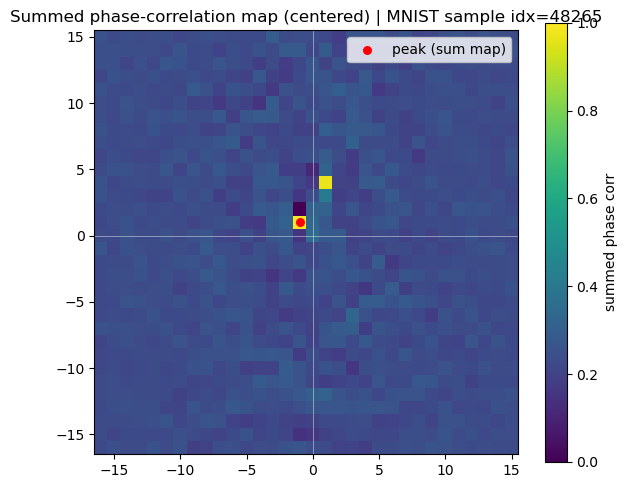

{'index': 48265,
 'gif_path': 'media/mnist_random_48265.gif',
 'seq': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.4863, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0667,  ..., 0.0078, 0.0000, 0.0000],
           [0.0000, 0.0196, 0.5529,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.7569, 0.0353, 0.0000,  ..., 0.6235, 0.9922, 0.9922],
           [0.2000, 0.0000, 0.0000,  ..., 0.9922, 0.9922, 0.7922],
           [0.0000, 0.0000, 0.0000,  ..., 0.9922, 0.5294, 0.0745]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.3529, 0.0078, 0.0000],
           [0.0000, 0.0000, 0.0196,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.3137,  ..., 0.3647, 0.0353, 0.0000],
           ...,
           [0.7922, 0.2000, 0.0000,  ..., 0.7961, 0.9922, 0.9922],
           [0.0745, 0.0000, 0.0000,  ..., 0.9961, 0.9922, 0.5294],
           [0.0000, 0.0000, 0.0000,  ..., 0.9961, 0.4863, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.4000, 0.0000, 0.0000],
           [0.00

In [26]:
show_random_mnist_with_phase_correlations(train_dataset_Mnist, subpixel=False, n_modes=2)

- test optical flow that return diffeomerphism vector field
- also test optical flow here globally 
- also apply globallly on the mnist the above phase correlation method
- apply the fft locally 

In [27]:

import cv2 as cv

# main opticalflow model
class VelocityExtractor:
    def __init__(self,
                 method="lk",
                 magnitude_threshold=0.5,
                 periodic_bc=False,
                 lk_params=None,
                 feature_params=None,
                 farneback_params=None):

        self.method = method
        self.magnitude_threshold = magnitude_threshold
        self.periodic_bc = periodic_bc

        # Default LK parameters
        self.feature_params = feature_params or dict(
            maxCorners=220,
            qualityLevel=0.08,
            minDistance=3,
            blockSize=3
        )

        self.lk_params = lk_params or dict(
            winSize=(15, 15),
            maxLevel=3,
            criteria=(cv.TERM_CRITERIA_EPS |
                      cv.TERM_CRITERIA_COUNT, 20, 0.03),
        )

        # Default Farneback parameters
        self.farneback_params = farneback_params or dict(
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

    # ==========================================================
    # Public API
    # ==========================================================
    def __call__(self, seq: torch.Tensor):
        return self.compute(seq)

    def compute(self, seq: torch.Tensor):
        """
        seq: (B, T, C, H, W)
        returns: (N_total, 2) torch tensor
        """

        device = seq.device
        B, T, C, H, W = seq.shape

        seq_np = seq.detach().cpu().numpy()
        all_disp = []

        for b in range(B):
            for t in range(T - 1):

                f0, f1 = self._prepare_frames(seq_np[b, t],
                                              seq_np[b, t + 1])

                if self.method == "lk":
                    disp = self._lk_step(f0, f1)

                elif self.method == "farneback":
                    disp = self._farneback_step(f0, f1)

                else:
                    raise ValueError("method must be 'lk' or 'farneback'")

                if disp.shape[0] > 0:
                    all_disp.append(disp)

        if len(all_disp) == 0:
            return torch.empty(0, 2, device=device)

        all_disp = np.vstack(all_disp)
        return torch.from_numpy(all_disp).float().to(device)

    # ==========================================================
    # Internal Helpers
    # ==========================================================
    def _prepare_frames(self, f0, f1):
        """
        Convert (C,H,W) numpy to grayscale uint8 (H,W)
        """

        if f0.shape[0] > 1:
            f0 = np.mean(f0, axis=0)
            f1 = np.mean(f1, axis=0)
        else:
            f0 = f0[0]
            f1 = f1[0]

        f0 = (255 * f0).astype(np.uint8)
        f1 = (255 * f1).astype(np.uint8)

        return f0, f1

    def _lk_step(self, f0, f1):

        p0 = cv.goodFeaturesToTrack(f0, mask=None,
                                    **self.feature_params)
        if p0 is None:
            return np.empty((0, 2), dtype=np.float32)

        p1, st, err = cv.calcOpticalFlowPyrLK(
            f0, f1, p0, None, **self.lk_params
        )

        if p1 is None or st is None:
            return np.empty((0, 2), dtype=np.float32)

        st = st.reshape(-1).astype(bool)
        good_new = p1[st].reshape(-1, 2)
        good_old = p0[st].reshape(-1, 2)

        if good_new.shape[0] == 0:
            return np.empty((0, 2), dtype=np.float32)

        disp = good_new - good_old

        if self.periodic_bc:
            h, w = f0.shape[:2]
            disp[:, 0] = (disp[:, 0] + w/2) % w - w/2
            disp[:, 1] = (disp[:, 1] + h/2) % h - h/2

        return disp.astype(np.float32)

    def _farneback_step(self, f0, f1):

        flow = cv.calcOpticalFlowFarneback(
            f0, f1, None, **self.farneback_params
        )

        disp = flow.reshape(-1, 2)

        mag = np.linalg.norm(disp, axis=1)
        keep = mag > self.magnitude_threshold
        disp = disp[keep]

        if disp.shape[0] == 0:
            return np.empty((0, 2), dtype=np.float32)

        if self.periodic_bc:
            h, w = f0.shape[:2]
            disp[:, 0] = (disp[:, 0] + w/2) % w - w/2
            disp[:, 1] = (disp[:, 1] + h/2) % h - h/2

        return disp.astype(np.float32)



In [28]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display
from PIL import Image as PILImage


def show_random_mnist_with_velocity_extractor(
    dataset,
    velocity_extractor,
    seed=None,
    fps=8,
    upscale=3,
    out_dir="media",
    k_top=10,
):
    """
    1) Shows one random MovingMNIST sequence as GIF
    2) Runs VelocityExtractor on it
    3) Plots displacement histogram
    4) Plots displacement vectors over first frame
    """

    import random
    if seed is not None:
        random.seed(seed)

    idx = random.randint(0, len(dataset) - 1)
    seq, label, true_vels = dataset[idx]  # (T,1,H,W)
    T, C, H, W = seq.shape

    os.makedirs(out_dir, exist_ok=True)

    # ---------------------------------------------------------
    # 1) Save MNIST sequence as GIF
    # ---------------------------------------------------------
    gif_path = os.path.join(out_dir, f"mnist_random_{idx}.gif")

    seq_np = seq.detach().cpu().numpy()
    seq_np = seq_np[:, 0]  # remove channel

    frames_u8 = (np.clip(seq_np, 0, 1) * 255).astype(np.uint8)

    pil_frames = []
    for frame in frames_u8:
        img = PILImage.fromarray(frame, mode="L")
        if upscale > 1:
            img = img.resize(
                (img.width * upscale, img.height * upscale),
                PILImage.NEAREST
            )
        pil_frames.append(img)

    duration_ms = int(1000 / max(fps, 1))
    pil_frames[0].save(
        gif_path,
        save_all=True,
        append_images=pil_frames[1:],
        duration=duration_ms,
        loop=0,
    )

    print(f"Random index: {idx}")
    print(f"Saved GIF: {gif_path}")
    display(Image(filename=gif_path))
    print("true vels", true_vels)

    # ---------------------------------------------------------
    # 2) Run VelocityExtractor
    # ---------------------------------------------------------
    seq_batch = seq.unsqueeze(0)  # add batch dim → (1,T,1,H,W)

    disp = velocity_extractor(seq_batch)  # (N_total, 2)

    if disp.shape[0] == 0:
        print("No displacements detected.")
        return

    disp_cpu = disp.detach().cpu()
    magnitudes = torch.norm(disp_cpu, dim=1)

    print(f"Total detected displacements: {len(magnitudes)}")

    # ---------------------------------------------------------
    # 3) Histogram of displacement magnitudes
    # ---------------------------------------------------------
    # ---------------------------------------------------------
    # 2D displacement histogram in R^2
    # ---------------------------------------------------------
    disp_cpu = disp.detach().cpu()
    dx = disp_cpu[:, 0].numpy()
    dy = disp_cpu[:, 1].numpy()

    # Define histogram range (centered at zero)
    max_range = max(abs(dx).max(), abs(dy).max()) + 1
    bins = 60

    H2d, xedges, yedges = np.histogram2d(
        dx, dy,
        bins=bins,
        range=[[-max_range, max_range], [-max_range, max_range]]
    )

    # Find top-k peaks in histogram
    flat = H2d.flatten()
    k = min(k_top, len(flat))
    topk_idx = np.argpartition(flat, -k)[-k:]

    peak_coords = []
    for idx_flat in topk_idx:
        ix = idx_flat // bins
        iy = idx_flat % bins

        x_center = 0.5 * (xedges[ix] + xedges[ix + 1])
        y_center = 0.5 * (yedges[iy] + yedges[iy + 1])

        peak_coords.append((x_center, y_center))

    print(f"Top-{k_top} displacement peaks:")
    for p in peak_coords:
        print(p)

    # ---------------------------------------------------------
    # Plot 2D histogram + peaks
    # ---------------------------------------------------------
    plt.figure(figsize=(6,6))

    plt.imshow(
        H2d.T,
        origin="lower",
        extent=[-max_range, max_range, -max_range, max_range],
        aspect="equal"
    )

    plt.colorbar(label="Count")

    # Mark peaks
    for px, py in peak_coords:
        plt.scatter(px, py, c="red", s=60)

    # Draw origin
    plt.scatter(0, 0, c="white", s=40)

    plt.title("2D Displacement Histogram in R^2")
    plt.xlabel("dx (pixels)")
    plt.ylabel("dy (pixels)")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4) Overlay displacement vectors on first frame
    # ---------------------------------------------------------
    first_frame = seq[0, 0].detach().cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(first_frame, cmap="gray")
    plt.title("Sample displacement vectors")

    # randomly sample some vectors for visualization
    num_show = min(100, disp_cpu.shape[0])
    idxs = torch.randperm(disp_cpu.shape[0])[:num_show]

    # random anchor positions (since LK doesn't return positions here)
    ys = np.random.randint(0, H, size=num_show)
    xs = np.random.randint(0, W, size=num_show)

    dx = disp_cpu[idxs, 0].numpy()
    dy = disp_cpu[idxs, 1].numpy()

    plt.quiver(xs, ys, dx, dy, color="red", angles='xy', scale_units='xy', scale=1)
    plt.xlim(0, W)
    plt.ylim(H, 0)
    plt.tight_layout()
    plt.show()

    return {
        "index": idx,
        "gif_path": gif_path,
        "num_displacements": len(magnitudes),
        # "topk_displacements": topk_vals.tolist(),
    }

Random index: 8805
Saved GIF: media/mnist_random_8805.gif


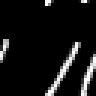

true vels tensor([[-3.,  1.],
        [ 2.,  0.]])
Total detected displacements: 122
Top-5 displacement peaks:
(-2.5472242355346664, 0.28302491505940885)
(1.9811744054158549, 0.28302491505940885)
(-3.1132740656534814, 1.415124575297039)
(1.9811744054158549, -0.2830249150594071)
(-3.1132740656534814, 0.8490747451782248)


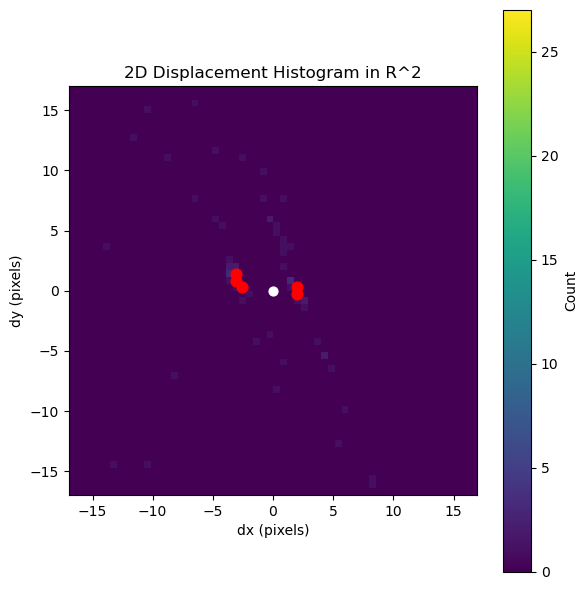

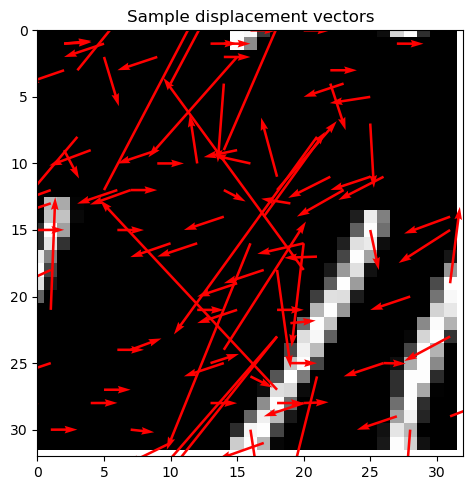

{'index': 8805,
 'gif_path': 'media/mnist_random_8805.gif',
 'num_displacements': 122}

In [29]:
show_random_mnist_with_velocity_extractor(train_dataset_Mnist, VelocityExtractor(method="lk", periodic_bc=True), seed=1, k_top=5)

In [30]:

class PhaseCorrelation(nn.Module):
    def __init__(self,
                 n_modes=2,
                 periodic_bc=True,
                 subpixel=True,
                 pad_factor=1,
                 eps=1e-8
                 ):
        
        super().__init__()
        self.n_modes = n_modes
        self.periodic_bc = periodic_bc
        self.subpixel = subpixel
        self.pad_factor = pad_factor
        self.eps = eps
    def _parabolic_subpixel(self, corr, y, x):
        """
        corr: (B, H, W)
        y, x: (B, n_modes)
        returns dy, dx of shape (B, n_modes)
        """
        B, H, W = corr.shape

        batch_idx = torch.arange(B, device=corr.device)[:, None]

        xm1 = (x - 1) % W
        xp1 = (x + 1) % W
        ym1 = (y - 1) % H
        yp1 = (y + 1) % H

        c = corr[batch_idx, y, x]

        c_xm1 = corr[batch_idx, y, xm1]
        c_xp1 = corr[batch_idx, y, xp1]
        denom_x = c_xm1 - 2 * c + c_xp1
        dx = torch.where(
            torch.abs(denom_x) < 1e-12,
            torch.zeros_like(denom_x),
            0.5 * (c_xm1 - c_xp1) / denom_x
        )

        c_ym1 = corr[batch_idx, ym1, x]
        c_yp1 = corr[batch_idx, yp1, x]
        denom_y = c_ym1 - 2 * c + c_yp1
        dy = torch.where(
            torch.abs(denom_y) < 1e-12,
            torch.zeros_like(denom_y),
            0.5 * (c_ym1 - c_yp1) / denom_y
        )

        return dy, dx
    

    def forward(self, seq):
        """
        seq: (B, T, C, H, W)

        Returns:
            velocities: (B, n_modes, 2)
        """

        B, T, C, H, W = seq.shape
        H_pad = H * self.pad_factor
        W_pad = W * self.pad_factor

        if C > 1:
            seq = seq.mean(dim=2)
        else:
            seq = seq[:, :, 0]  # (B, T, H, W)

        F_seq = torch.fft.rfft2(seq, s=(H_pad, W_pad))
        # shape: (B, T, H_pad, W_pad//2+1)

        # for all the sequence pairs, 
        F_prev = F_seq[:, :-1]
        F_next = F_seq[:, 1:]

        R = F_prev * torch.conj(F_next)
        R = R / (torch.abs(R) + self.eps)

        R_sum = R.sum(dim=1)   # (B, H_pad, W_pad//2+1)

        corr_sum = torch.fft.irfft2(R_sum, s=(H_pad, W_pad))
        # (B, H_pad, W_pad)

        corr_flat = corr_sum.view(B, -1)
        top_vals, topk_idx = torch.topk(corr_flat, self.n_modes, dim=1)

        y0 = topk_idx // W_pad
        x0 = topk_idx % W_pad

        y = y0.float()
        x = x0.float()

        # Subpixel refinement
        if self.subpixel:
            dy, dx = self._parabolic_subpixel(corr_sum, y0, x0)
            y = y + dy
            x = x + dx

        # Periodic wrap correction
        if self.periodic_bc:
            x = torch.where(x > W_pad / 2, x - W_pad, x)
            y = torch.where(y > H_pad / 2, y - H_pad, y)

        # Convert shift → velocity
        vx = -x
        vy = -y
        velocities = torch.stack([vx, vy], dim=2)


        return velocities, top_vals, corr_sum # (B, n_modes, 2)



In [31]:
# Create datasets for each split
train_dataset = KTHVideoClips(
    Path("./data/kth/"), 
    seq_len=16, 
    height=32, 
    width=32, 
    step=2, 
    split='train',
    vx_data_range=0,
    vy_data_range=0,
    split_method='person'
)


Loading dataset into memory...


Loading videos:   0%|          | 0/599 [00:00<?, ?it/s]

Loading videos: 100%|██████████| 599/599 [00:02<00:00, 259.19it/s]

Loaded 1,517 valid subsequences for train split using person method.
Dataset loaded into memory. Total size: 0.28 GB


In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import random


def visualize_phasecorr_sample(
    dataset,
    model,
    device="cpu",
    n_modes=None,
    log_corr=True
):
    """
    Visualize:
      1) sequence animation (JS-based, notebook-safe)
      2) phase correlation histogram (centered)
      3) predicted velocities + strengths

    Assumes model.forward returns:
      velocities, top_vals, corr_sum
    """

    model.eval()
    model.to(device)

    # ---- sample random item ----
    idx = random.randint(0, len(dataset) - 1)
    seq, _ = dataset[idx]          # (T, 1, H, W)
    T, C, H, W = seq.shape

    seq_batch = seq.unsqueeze(0).to(device)  # (1,T,1,H,W)

    with torch.no_grad():
        velocities, top_vals, corr_sum = model(seq_batch)

    velocities = velocities[0].cpu().numpy()   # (n_modes, 2)
    strengths  = top_vals[0].cpu().numpy()
    corr = corr_sum[0].cpu().numpy()

    if n_modes is None:
        n_modes = velocities.shape[0]

    # ============================================================
    # 1) SEQUENCE ANIMATION (JS HTML — ALWAYS WORKS)
    # ============================================================

    fig, ax = plt.subplots()
    im = ax.imshow(seq[0, 0], cmap="gray", animated=True)
    ax.set_title("KTH sample sequence")
    ax.axis("off")

    def update(t):
        im.set_array(seq[t, 0])
        ax.set_title(f"Frame {t}")
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=T,
        interval=200,
        blit=True
    )

    plt.close(fig)
    display(HTML(ani.to_jshtml()))

    # ============================================================
    # 2) CORRELATION HISTOGRAM (CENTERED, CORRECT AXES)
    # ============================================================

    Hc, Wc = corr.shape
    cy, cx = Hc // 2, Wc // 2

    corr_centered = np.roll(np.roll(corr, -cy, axis=0), -cx, axis=1)

    if log_corr:
        corr_centered = np.log(corr_centered - corr_centered.min() + 1e-6)

    fig, ax = plt.subplots(figsize=(6, 6))
    extent = [-Wc//2, Wc//2, -Hc//2, Hc//2]

    im = ax.imshow(
        corr_centered,
        extent=extent,
        origin="lower",
        cmap="viridis"
    )
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)

    plt.colorbar(im, ax=ax, label="Correlation")

    ax.set_xlabel("x displacement (→ positive)")
    ax.set_ylabel("y displacement (↑ positive)")
    ax.set_title("Phase Correlation (centered)")

    # ============================================================
    # 3) OVERLAY VELOCITIES + STRENGTHS
    # ============================================================

    for k in range(n_modes):
        vx, vy = velocities[k]

        ax.plot(-vx, -vy, "ro")
        ax.text(
            vx + 0.3,
            vy + 0.3,
            f"{strengths[k]:.2e}",
            color="white",
            fontsize=8
        )

    plt.show()

    return idx, velocities, strengths

In [33]:
# Create datasets for each split
train_dataset = KTHVideoClips(
    Path("./data/kth/"), 
    seq_len=16, 
    height=32, 
    width=32, 
    step=2, 
    split='train',
    vx_data_range=0,
    vy_data_range=0,
    split_method='person'
)


Loading dataset into memory...


Loading videos: 100%|██████████| 599/599 [00:02<00:00, 269.99it/s]


Loaded 1,517 valid subsequences for train split using person method.
Dataset loaded into memory. Total size: 0.28 GB


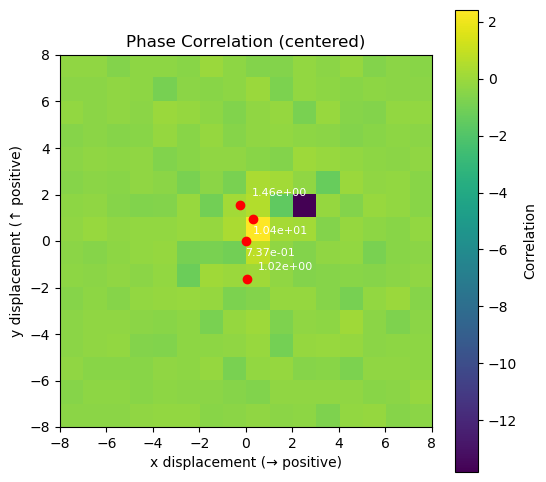

(204,
 array([[ 0.00277971,  0.01189734],
        [-0.05957918,  1.6374416 ],
        [ 0.2296396 , -1.5314815 ],
        [-0.31615844, -0.95251226]], dtype=float32),
 array([10.434459 ,  1.4612877,  1.0238516,  0.7366346], dtype=float32))

In [50]:

phacecorr = PhaseCorrelation(n_modes=4, periodic_bc=True, subpixel=True)
visualize_phasecorr_sample(train_dataset, phacecorr, device="cpu")